In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Path to the dataset
data_path = r"C:\Users\91962\Desktop\DS_AI_Internship\SRC\day20\customer_analytics.csv"

# Load dataset
if os.path.exists(data_path):
    df = pd.read_csv(data_path, sep="\t")
    print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
    print(df.head())
else:
    print(f"Error: Dataset not found at {data_path}. Please run the generator first.")
print(df.head())

Dataset loaded with 5 rows and 4 columns.
   CustomerID  Age  Gender    City
0        1001   49    Male    Pune
1        1002   44    Male    Pune
2        1003   42    Male  Mumbai
3        1004   36  Female  Mumbai
4        1005   23    Male    Pune
   CustomerID  Age  Gender    City
0        1001   49    Male    Pune
1        1002   44    Male    Pune
2        1003   42    Male  Mumbai
3        1004   36  Female  Mumbai
4        1005   23    Male    Pune


In [3]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
pd.DataFrame({'Missing Count': missing_values, 'Percentage (%)': missing_percentage.round(2)})

,Missing Count,Percentage (%)
CustomerID,0,0.0
Age,0,0.0
Gender,0,0.0
City,0,0.0


In [4]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")

Number of duplicate rows found: 0


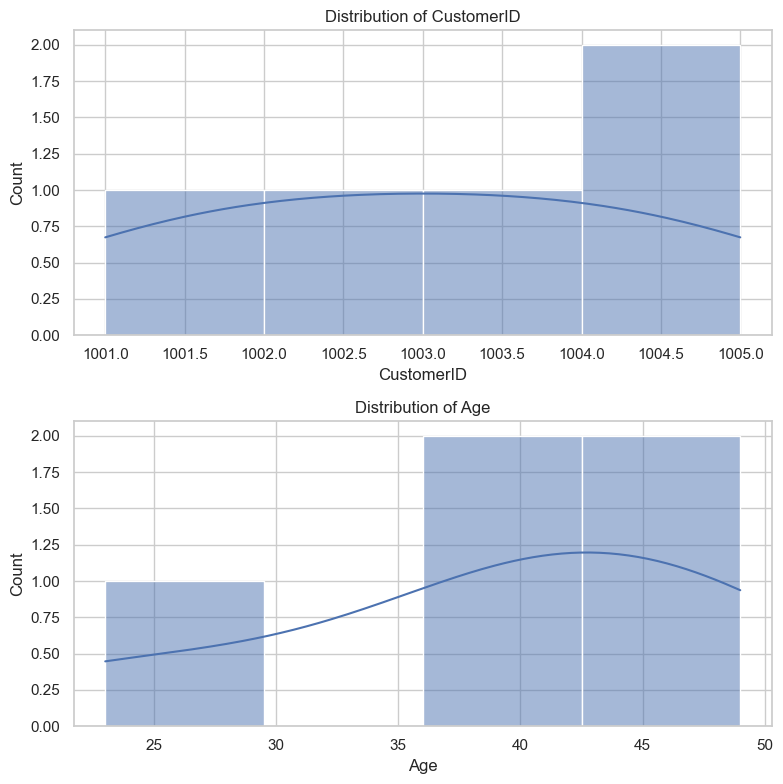

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(nrows=len(numerical_cols), ncols=1, figsize=(8, 4*len(numerical_cols)))

if len(numerical_cols) == 1:
    axes = [axes]

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

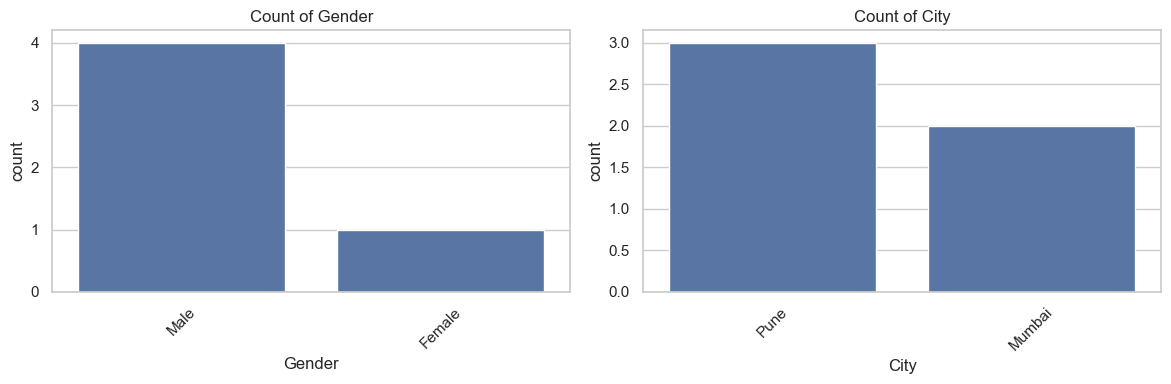

In [9]:
cat_cols = df.select_dtypes(include='object').columns

fig, axes = plt.subplots(nrows=1, ncols=len(cat_cols), figsize=(6*len(cat_cols), 4))

if len(cat_cols) == 1:
    axes = [axes]

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Count of {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

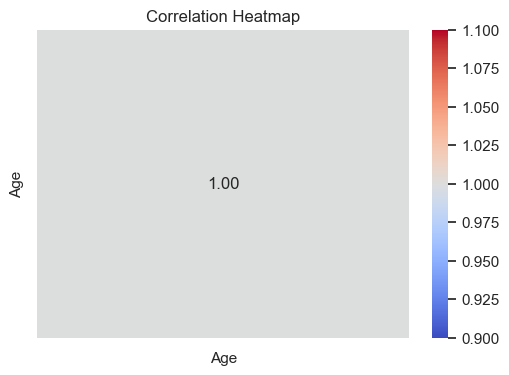

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Drop ID column (important)
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['CustomerID'])

plt.figure(figsize=(6, 4))

correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

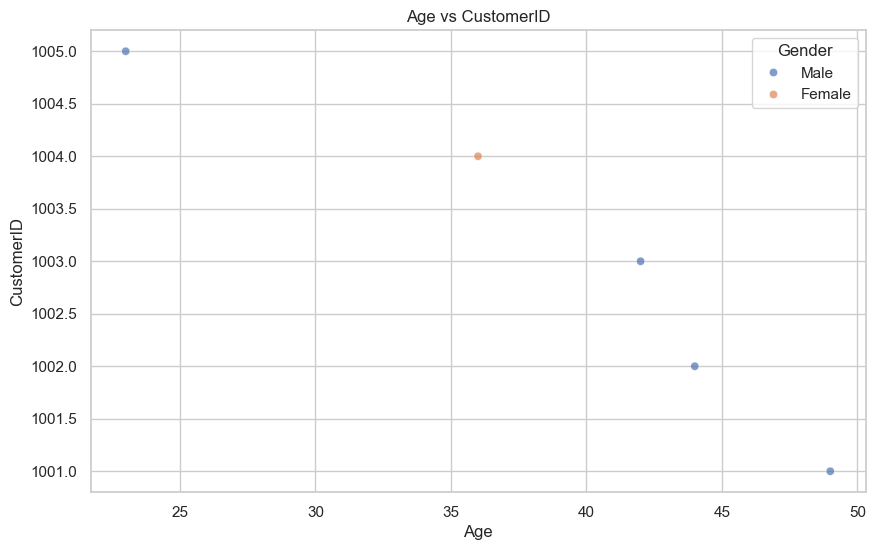

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(data=df, x='Age', y='CustomerID', hue='Gender', alpha=0.7)

plt.title("Age vs CustomerID")
plt.show()

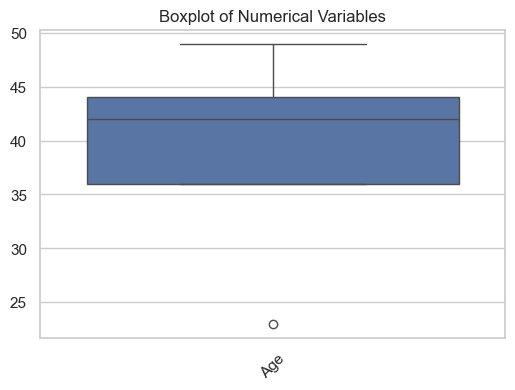

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numerical_cols = df.select_dtypes(include=[np.number]).columns

# Remove CustomerID if present
numerical_cols = numerical_cols.drop('CustomerID', errors='ignore')

plt.figure(figsize=(6, 4))

sns.boxplot(data=df[numerical_cols])

plt.title("Boxplot of Numerical Variables")
plt.xticks(rotation=45)
plt.show()